# Week 3: Machine Learning for AI

## Titanic Survival Prediction using Logistic Regression

This project applies a machine learning classification model to predict passenger survival on the Titanic dataset.

## Data Loading and Inspection

In this section, the cleaned Titanic dataset is loaded and inspected to understand its structure and variables.

In [ ]:
import pandas as pd

df = pd.read_csv('Titanic_Dataset Cleaned. CSV.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [ ]:
df.shape

(891, 11)

## Data Preprocessing

Categorical variables are converted into numerical values to make them suitable for machine learning algorithms.

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S


## Feature Selection

The selected features include passenger class, sex, age, and fare, while survival status serves as the target variable.

In [ ]:
X = df[['Pclass','Sex','Age','Fare']]

y = df['Survived']

## Train-Test Split

The dataset was divided into training and testing sets to evaluate the model's performance on unseen data. The training set (80%) was used to train the Logistic Regression model, while the testing set (20%) was used to assess how well the model generalizes to new observations.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(712, 4)
(179, 4)


The dataset was successfully split into training and testing subsets. This helps prevent overfitting and provides a reliable assessment of model performance.

## Model Training

A Logistic Regression model is trained using the training dataset.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

## Model Evaluation

The model is evaluated using Accuracy, Precision, and Recall metrics.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



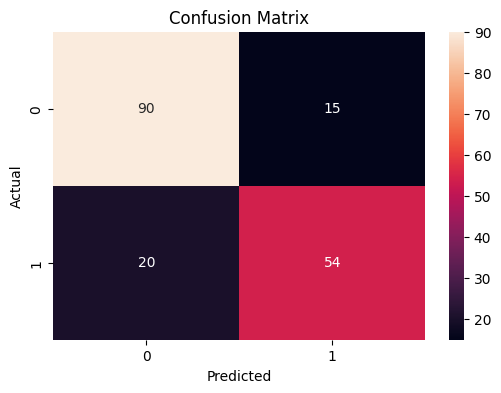

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Feature Importance Analysis

This section examines the influence of each feature on the model's predictions.

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,Sex,2.465606
0,Pclass,0.996326
2,Age,0.025163
3,Fare,0.001183


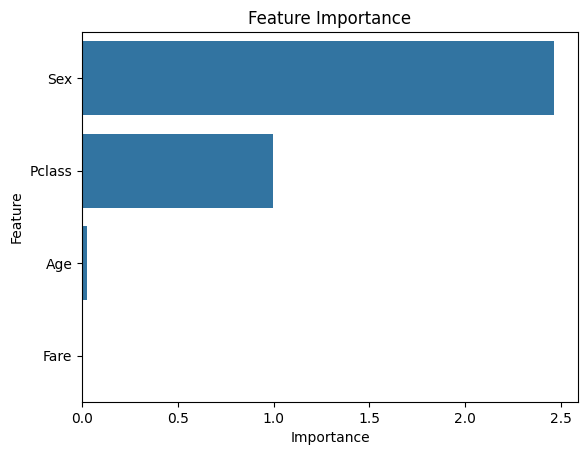

In [ ]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

## Conclusion

A Logistic Regression model was successfully trained to predict passenger survival using the Titanic dataset.

The model was evaluated using Accuracy, Precision, and Recall metrics.

Feature importance analysis showed which variables contributed most to survival prediction.

This project demonstrates the application of supervised machine learning for a classification problem.